In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# =====================================================
# Load Dataset & Basic Preprocessing
# ==============================================3=======

df = pd.read_csv('../Data/data.csv')

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)   

df['StateHoliday'] = df['StateHoliday'].astype(str)

D:\Temp\ipykernel_10028\1650621996.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


In [4]:
print("Total Customers:",df["Customers"].sum())
print("Avg Customers:",df["Customers"].mean())
print("std :",df["Customers"].std())
print("Max Customers:",df["Customers"].max())
print("Min Customers:",df["Customers"].min())

Total Customers: 496493396
Avg Customers: 635.8541959891346
std : 467.8152825631848
Max Customers: 7388
Min Customers: 0


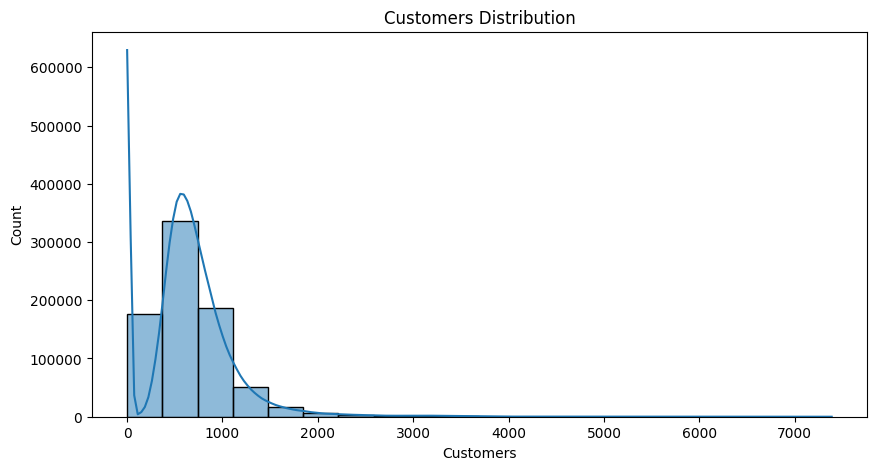

In [5]:
# Customers Distribution:
plt.figure(figsize=(10,5))
sns.histplot(df["Customers"], bins=20, kde=True)
plt.title("Customers Distribution")
plt.show()

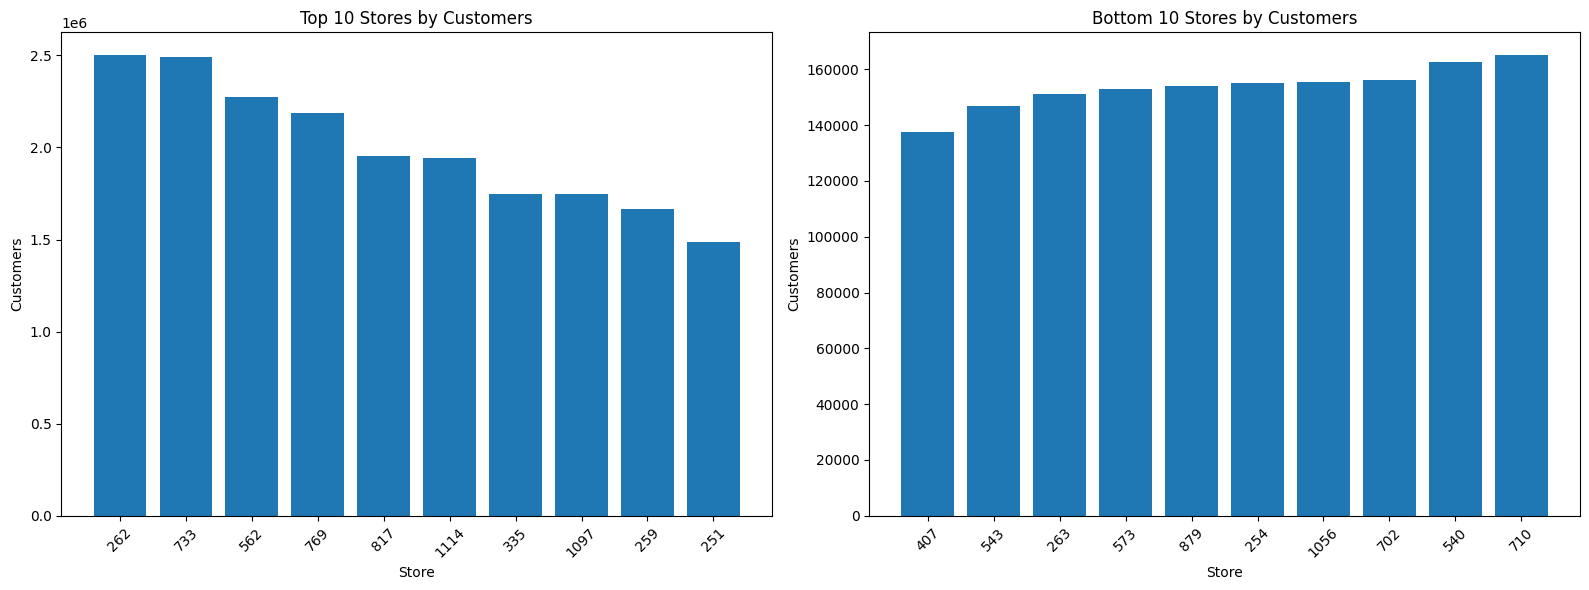

Store
262     2499769
733     2491596
562     2271072
769     2186356
817     1952737
1114    1943137
335     1746303
1097    1746229
259     1663060
251     1484902
Name: Customers, dtype: int64
Store
407     137596
543     146877
263     151242
573     152963
879     154155
254     155188
1056    155591
702     156078
540     162510
710     164962
Name: Customers, dtype: int64


In [6]:
# Top 10 Stores
top10 = df.groupby("Store")["Customers"].sum().sort_values(ascending=False).head(10)

# Bottom 10 Stores
bottom10 =df.groupby("Store")["Customers"].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(16,6))

# Top 10
plt.subplot(1,2,1)
plt.bar(top10.index.astype(str), top10.values)
plt.title("Top 10 Stores by Customers")
plt.xlabel("Store")
plt.ylabel("Customers")
plt.xticks(rotation=45)

# Bottom 10
plt.subplot(1,2,2)
plt.bar(bottom10.index.astype(str), bottom10.values)
plt.title("Bottom 10 Stores by Customers")
plt.xlabel("Store")
plt.ylabel("Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(top10)
print(bottom10)

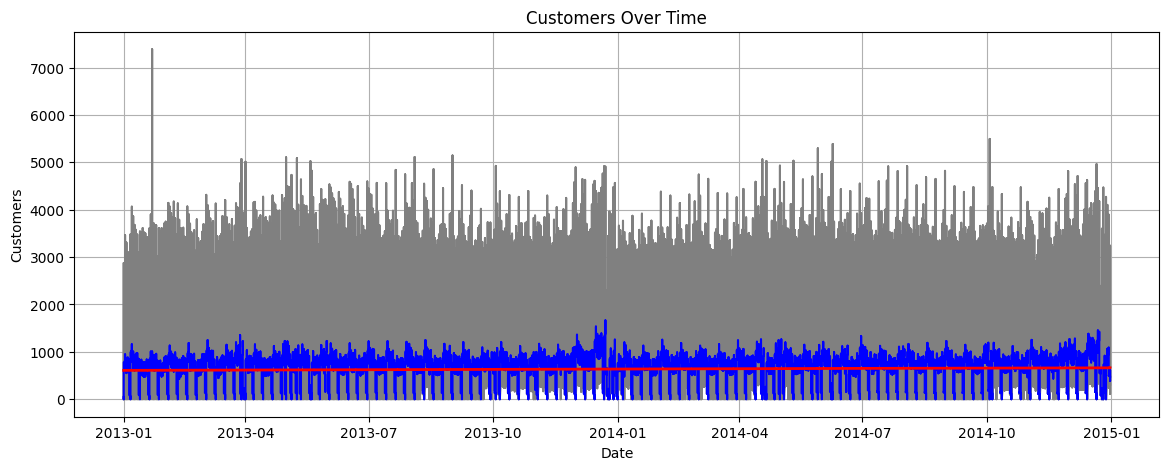

Slope: -0.0001


In [7]:
# Customers Trend:
x = np.arange(len(df))
y = df['Customers'].values
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.polyval(coeffs, x)

df['SMA_7'] = df['Customers'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Customers'], color='grey')
plt.plot(df['SMA_7'], label='SMA 7-day', color='blue')
plt.plot(df.index, trend_line, label='Trend Line (deg=1)', 
         color='red', linewidth=2)

plt.title("Customers Over Time")
plt.xlabel("Date")
plt.ylabel("Customers")
plt.grid()
plt.show()

print(f"Slope: {coeffs[0]:.4f}")

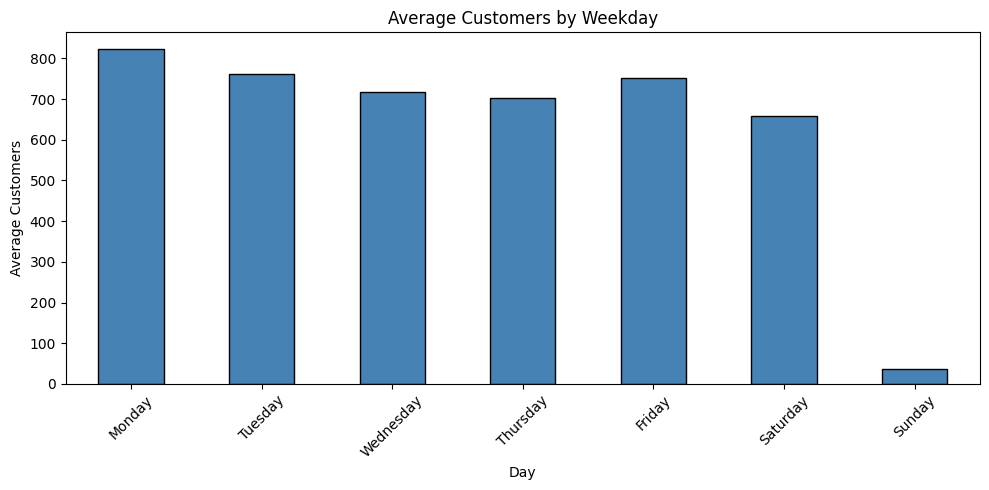

weekday
Monday       822.873751
Tuesday      762.464461
Wednesday    716.580252
Thursday     701.840403
Friday       751.843215
Saturday     658.022933
Sunday        35.613408
Name: Customers, dtype: float64


In [8]:
df['weekday'] = df.index.day_name()

weekday_order = ['Monday','Tuesday','Wednesday',
                 'Thursday','Friday','Saturday','Sunday']

weekday_avg = df.groupby('weekday')['Customers'].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

# Plot
plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Customers by Weekday')
plt.xlabel('Day')
plt.ylabel('Average Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_avg)
df.drop("weekday", axis=1, inplace=True)

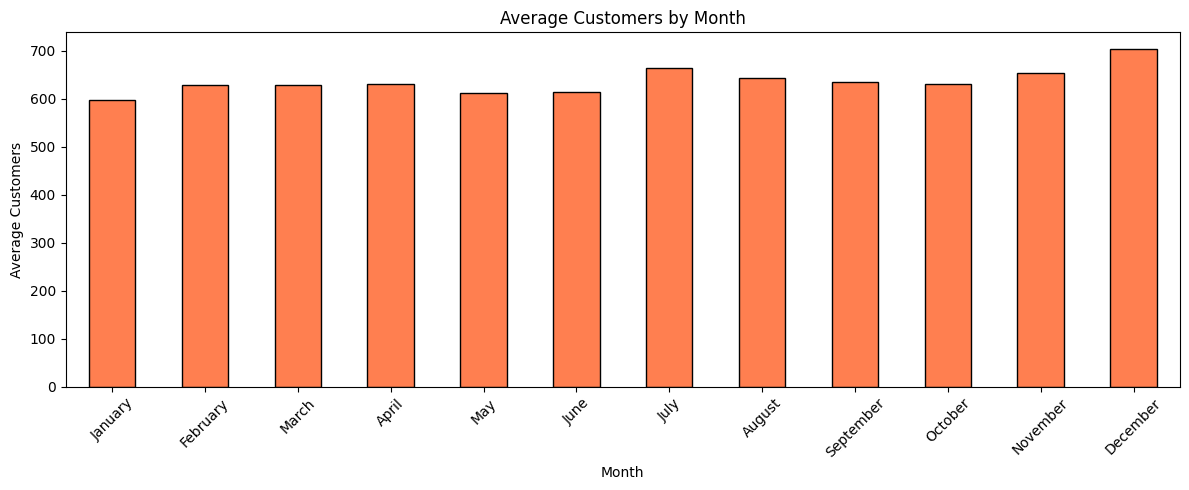

month
January      597.052033
February     628.071076
March        628.615579
April        631.211031
May          610.872790
June         613.646607
July         663.593124
August       642.496979
September    634.438699
October      631.095987
November     654.147967
December     703.067899
Name: Customers, dtype: float64


In [9]:
df['month'] = df.index.month_name()

month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

month_avg = df.groupby('month')['Customers'].mean()
month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,5))
month_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Customers by Month')
plt.xlabel('Month')
plt.ylabel('Average Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(month_avg)
df.drop("month", axis=1, inplace=True)

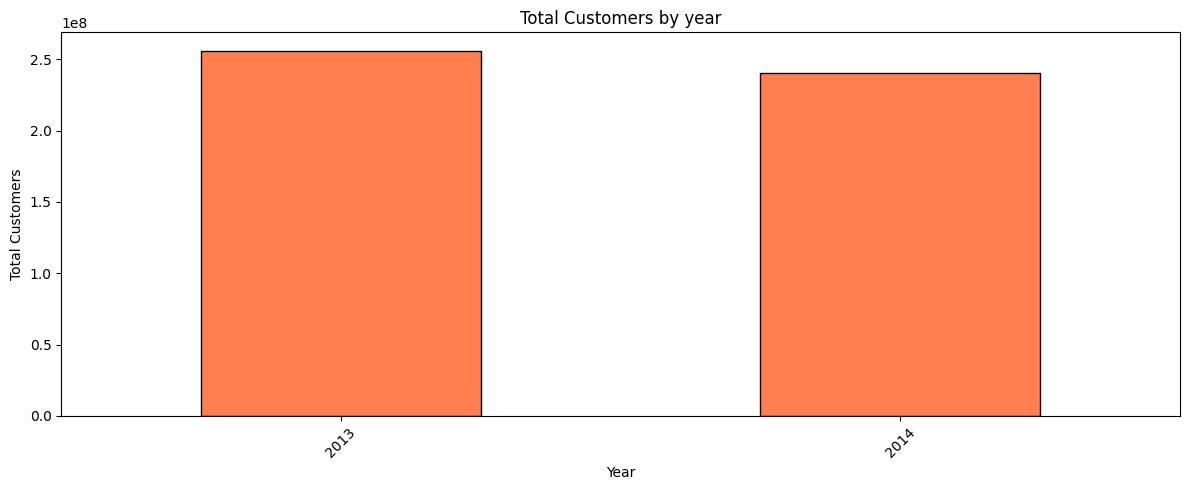

year
2013    256004425
2014    240488971
Name: Customers, dtype: int64


In [10]:
df['year'] = df.index.year

customers_yearly = df.groupby('year')['Customers'].sum()

plt.figure(figsize=(12,5))
customers_yearly.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Total Customers by year')
plt.xlabel('Year')
plt.ylabel('Total Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(customers_yearly)
df.drop("year", axis=1, inplace=True)

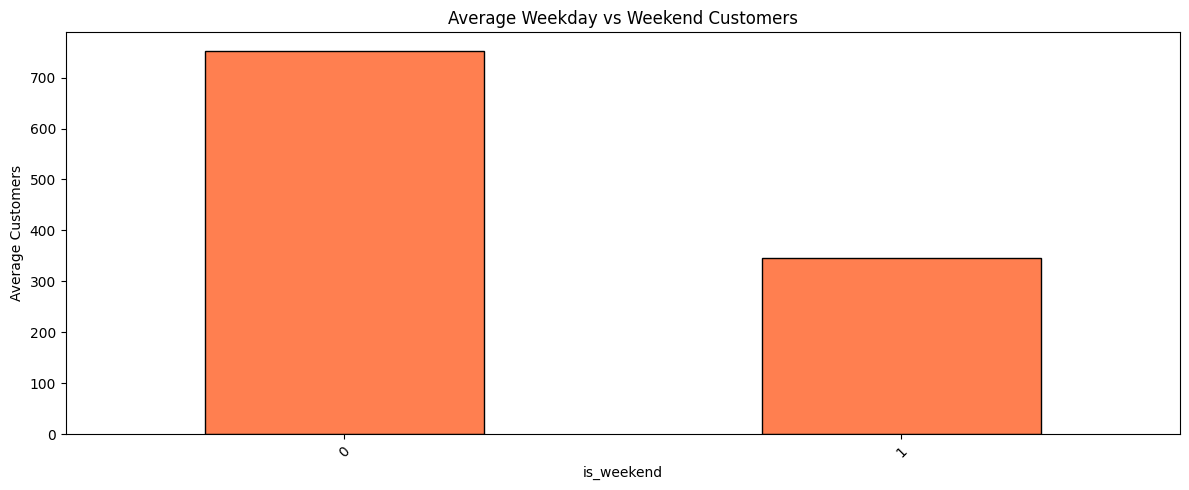

is_weekend
0    751.081547
1    346.818170
Name: Customers, dtype: float64


In [11]:
df["day_of_week"] = df.index.day_of_week
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

weekend = df.groupby('is_weekend')['Customers'].mean()

plt.figure(figsize=(12,5))
weekend.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Weekday vs Weekend Customers')
plt.ylabel('Average Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekend)
df.drop("day_of_week", axis=1, inplace=True)
df.drop("is_weekend", axis=1, inplace=True)

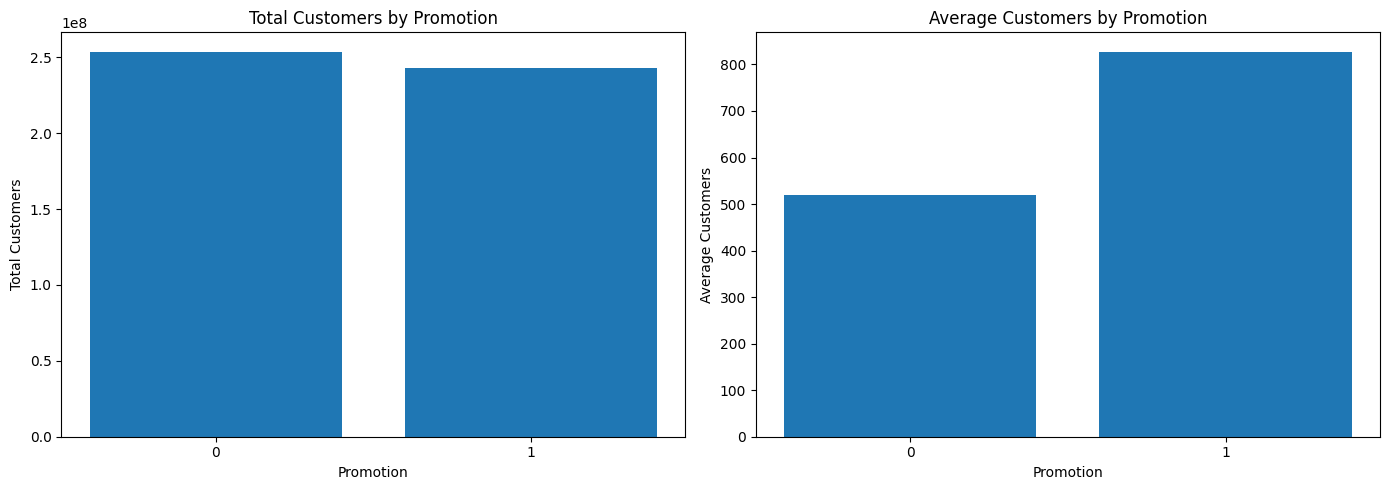

   Promo  Total_Customers  Average_Customers
0      0        253738009         520.462601
1      1        242755387         827.655127


In [12]:
promo_analysis = df.groupby('Promo')['Customers'].agg(Total_Customers='sum', Average_Customers='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Customers ----------------
ax[0].bar(
    promo_analysis['Promo'].astype(str),
    promo_analysis['Total_Customers']
)
ax[0].set_title("Total Customers by Promotion")
ax[0].set_xlabel("Promotion")
ax[0].set_ylabel("Total Customers")

# ---------------- Average Customers ----------------
ax[1].bar(
    promo_analysis['Promo'].astype(str),
    promo_analysis['Average_Customers']
)

ax[1].set_title("Average Customers by Promotion")
ax[1].set_xlabel("Promotion")
ax[1].set_ylabel("Average Customers")

plt.tight_layout()
plt.show()

print(promo_analysis)

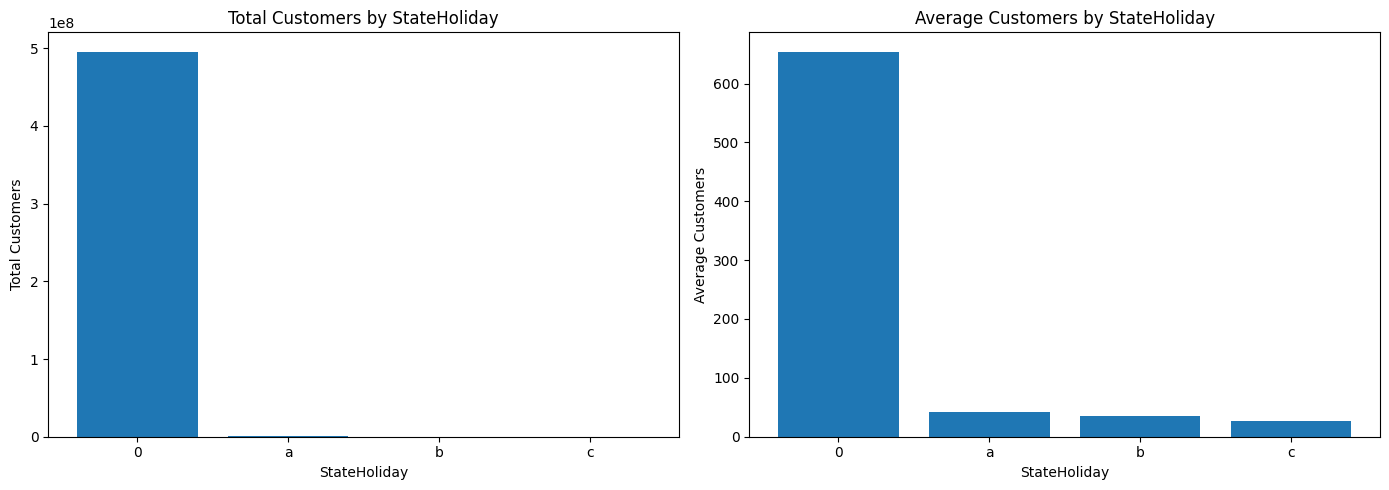

  StateHoliday  Total_Customers  Average_Customers
0            0        495590945         654.238562
1            a           632009          42.816137
2            b           159027          35.656278
3            c           111415          27.174390


In [13]:
StateHoliday_analysis = df.groupby('StateHoliday')['Customers'].agg(Total_Customers='sum', Average_Customers='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Customers ----------------
ax[0].bar(
    StateHoliday_analysis['StateHoliday'].astype(str),
    StateHoliday_analysis['Total_Customers']
)
ax[0].set_title("Total Customers by StateHoliday")
ax[0].set_xlabel("StateHoliday")
ax[0].set_ylabel("Total Customers")

# ---------------- Average Customers ----------------
ax[1].bar(
    StateHoliday_analysis['StateHoliday'].astype(str),
    StateHoliday_analysis['Average_Customers']
)

ax[1].set_title("Average Customers by StateHoliday")
ax[1].set_xlabel("StateHoliday")
ax[1].set_ylabel("Average Customers")

plt.tight_layout()
plt.show()

print(StateHoliday_analysis)

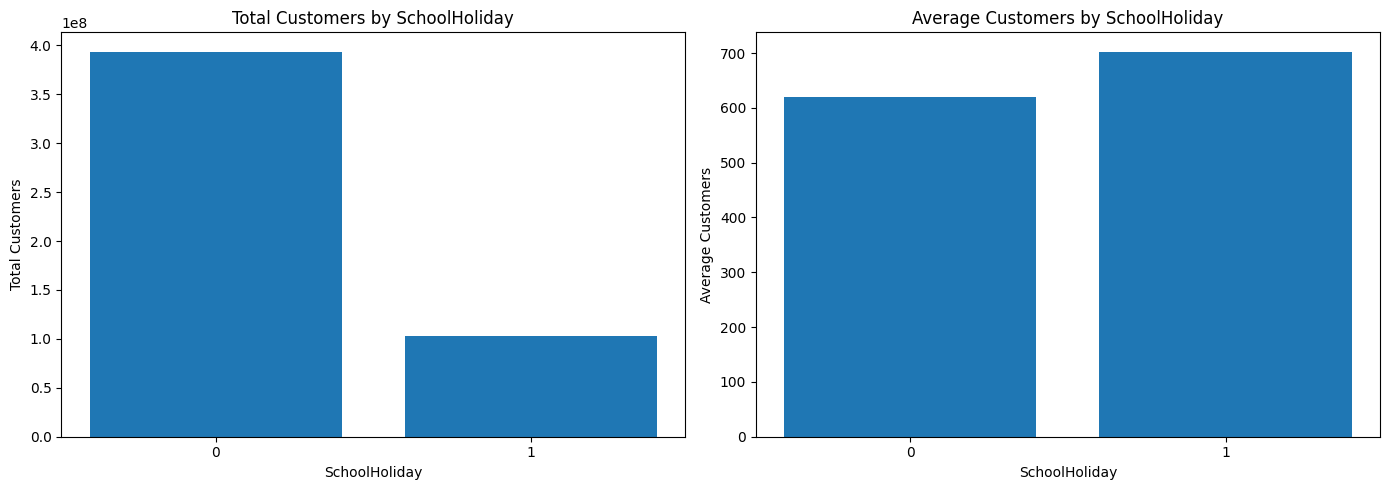

   SchoolHoliday  Total_Customers  Average_Customers
0              0        393589790         620.421459
1              1        102903606         702.711086


In [14]:
SchoolHoliday_analysis = df.groupby('SchoolHoliday')['Customers'].agg(Total_Customers='sum', Average_Customers='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Customers ----------------
ax[0].bar(
    SchoolHoliday_analysis['SchoolHoliday'].astype(str),
    SchoolHoliday_analysis['Total_Customers']
)
ax[0].set_title("Total Customers by SchoolHoliday")
ax[0].set_xlabel("SchoolHoliday")
ax[0].set_ylabel("Total Customers")

# ---------------- Average Customers ----------------
ax[1].bar(
    SchoolHoliday_analysis['SchoolHoliday'].astype(str),
    SchoolHoliday_analysis['Average_Customers']
)

ax[1].set_title("Average Customers by SchoolHoliday")
ax[1].set_xlabel("SchoolHoliday")
ax[1].set_ylabel("Average Customers")

plt.tight_layout()
plt.show()

print(SchoolHoliday_analysis)

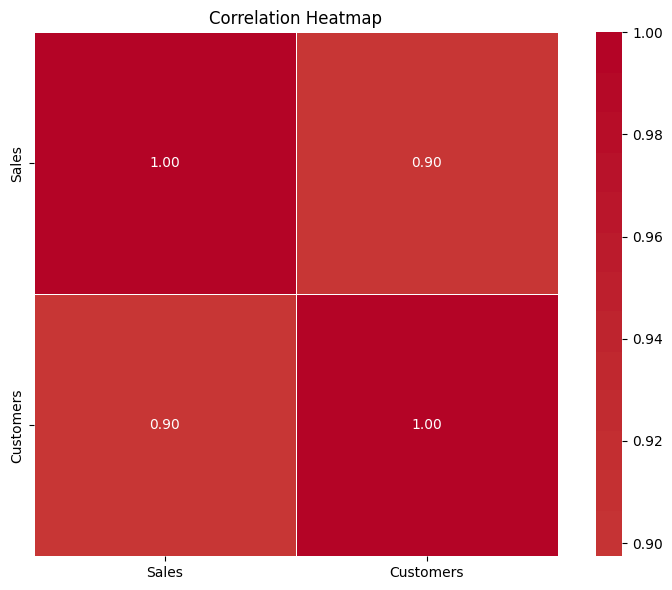

Correlation between Sales & Customers:
              Sales  Customers
Sales      1.000000   0.897413
Customers  0.897413   1.000000


In [16]:
# Correlation
corr = df[['Sales', 'Customers']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


print("Correlation between Sales & Customers:")
print(corr)

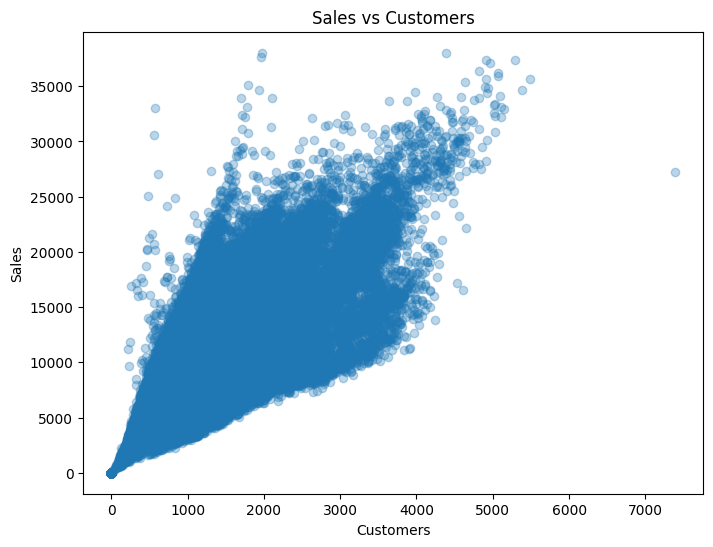

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Customers'],
    df['Sales'],
    alpha=0.3
)

plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Sales vs Customers")

plt.show()